<a href="https://colab.research.google.com/github/willvw/DataSci101/blob/HW5/Copy_of_hw9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW9



> Back Bay National Wildlife Refuge is located in the southeastern corner of the City of Virginia Beach. The refuge was established in 1938 to protect and provide habitat for migrating and wintering waterfowl. Diverse habitats, including beachfront, freshwater marsh, dunes, shrub-scrub and upland forest are home to hundreds of species of birds, reptiles, amphibians, mammals and fish.

![BNWR](https://www.fws.gov/sites/default/files/styles/banner_image_xl/public/banner_images/2020-09/waterfowl%20%28tundras%29.jpg?h=0c8d0f81&itok=NcZlpD27)


To get introduced to the park and its history, please view the following interactive story map.

[BBNWR History and Introduction](https://storymaps.arcgis.com/stories/960d9db38cca4f3d8d38111119b9874f)

Additionally, here is some drone footage of the park for a better look at the geography and ecology of the area.

[BBNWR Drone Footage](https://www.youtube.com/watch?v=NlW330aBTCc)

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sb
import random
random.seed(101)

In [2]:
bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/lab-09/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace("d", "D")

## Question 1

### Part (a)

Compute the proportions of each value of the `Site_ID` variable.

In [3]:
# answer
site_id_proportions = bbnwr["Site_Id"].value_counts(normalize=True)
print(site_id_proportions)

Site_Id
Bay    0.335021
D      0.186076
B      0.184388
A      0.183122
C      0.111392
Name: proportion, dtype: float64


Interpret these values as **means**. For example, what **mean** is being calculated when we find that the proportion of observations from the Bay is 0.335?

**ANSWER:**

When interpreting the proportion of observations from the Bay as 0.335, it means that 33.5% of the total observations in the dataset belong to the category "Bay" under the Site_Id variable.

### Part (b)

Write a series of simulations of sampling from the `bbnwr` data (treating it as a population) for the following sample sizes:

In [4]:
ns = [2, 10, 25, 100, 1000, 5000]

* To make the `bbnwr` table an infinitely large population, use `replace = True` when using `.sample()`. Repeat the sampling process 1000 times for each sample size.
* For each sample, compute the proportion from the Bay. (We will use these proportions in future problems, so save it to a variable.)

In [6]:
# simulation
import pandas as pd
import numpy as np

bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/lab-09/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace("d", "D")

# Define sample sizes and number of iterations
sample_sizes = [10, 50, 100, 500, 1000]
num_iterations = 1000

# Dictionary to store Bay proportions for each sample size
bay_proportions = {size: [] for size in sample_sizes}

for size in sample_sizes:
    for _ in range(num_iterations):

        sample = bbnwr.sample(n=size, replace=True)

        bay_proportion = (sample["Site_Id"] == "Bay").mean()
        bay_proportions[size].append(bay_proportion)

bay_proportions_df = pd.DataFrame(bay_proportions)
print(bay_proportions_df.head())

   10    50    100    500    1000
0   0.4  0.32  0.35  0.318  0.354
1   0.2  0.26  0.29  0.366  0.352
2   0.2  0.28  0.28  0.322  0.346
3   0.3  0.26  0.29  0.336  0.351
4   0.1  0.38  0.37  0.308  0.313


We know the population proportion of measurements from the Bay is 0.335021. For each sample size, verify that that the average sample proportion is approximately 0.34

In [8]:
# mean of proportions
# Calculate average proportions for each sample size
average_proportions = bay_proportions_df.mean().round(4)

# Create comparison table
results = pd.DataFrame({
    'Sample Size': sample_sizes,
    'Average Proportion': average_proportions.values,

})

print(results)

   Sample Size  Average Proportion
0           10              0.3336
1           50              0.3352
2          100              0.3332
3          500              0.3335
4         1000              0.3344


For each sample size, compute the **standard error** (the standard deviation of the sampling distribution). Display these standard deviations as a table or graph.

   Sample Size  Standard Error
0           10        0.151092
1           50        0.065848
2          100        0.046013
3          500        0.022145
4         1000        0.015050


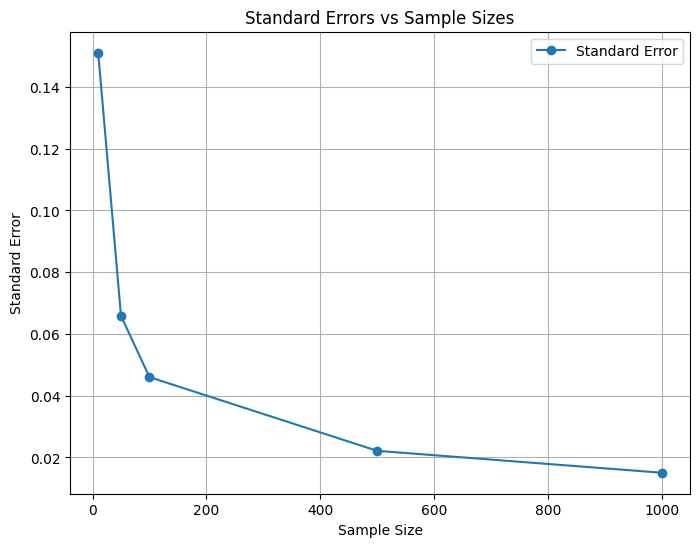

In [9]:
# standard errors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/lab-09/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace("d", "D")

# Define sample sizes and number of iterations
sample_sizes = [10, 50, 100, 500, 1000]
num_iterations = 1000

# Dictionary to store Bay proportions for each sample size
bay_proportions = {size: [] for size in sample_sizes}

# Perform bootstrap sampling for each sample size
for size in sample_sizes:
    for _ in range(num_iterations):
        # Sample with replacement
        sample = bbnwr.sample(n=size, replace=True)
        # Calculate proportion of "Bay" in the sample
        bay_proportion = (sample["Site_Id"] == "Bay").mean()
        bay_proportions[size].append(bay_proportion)

# Calculate standard errors (standard deviation of sampling distributions)
standard_errors = {size: np.std(bay_proportions[size], ddof=1) for size in sample_sizes}

# Create a table of standard errors
standard_errors_df = pd.DataFrame({
    "Sample Size": sample_sizes,
    "Standard Error": [standard_errors[size] for size in sample_sizes]
})

print(standard_errors_df)

# Plot the standard errors
plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, [standard_errors[size] for size in sample_sizes], marker='o', label="Standard Error")
plt.title("Standard Errors vs Sample Sizes")
plt.xlabel("Sample Size")
plt.ylabel("Standard Error")
plt.grid(True)
plt.legend()
plt.show()

What do you notice as the sample size gets large?

**ANSWER:**

- Standard Error Decreases
- Narrower Confidence Intervals
- Sampling Distribution Becomes Less Spread Out

### Part (c)

Continuing to use the simulations from Part (b), plot the sampling distribution of the sample proportions of measurments from the Bay.

#### $n = 2$

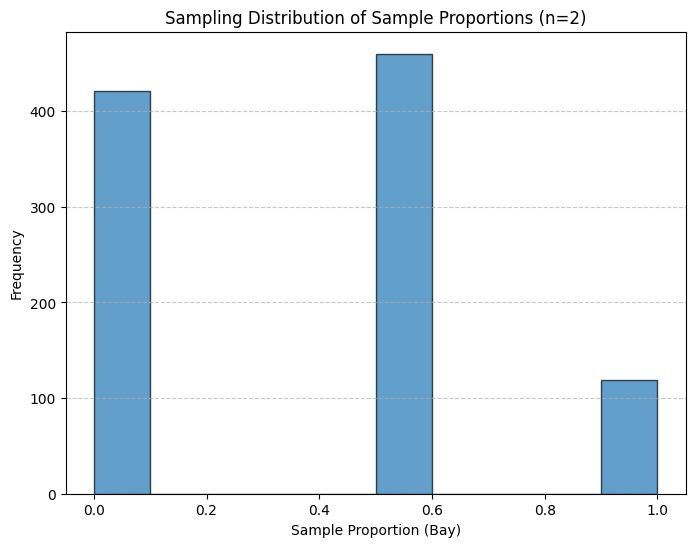

In [10]:
# plot
sample_size = 2
num_iterations = 1000

# Perform bootstrap sampling with n=2 and compute proportions from "Bay"
bay_proportions_n2 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n2.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n2, bins=10, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=2)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### $n = 10$

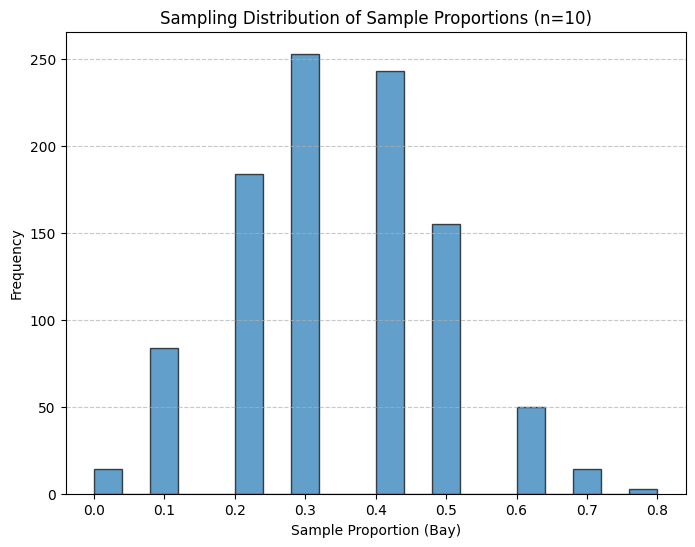

In [11]:
# plot
sample_size = 10
num_iterations = 1000

# Perform bootstrap sampling with n=10 and compute proportions from "Bay"
bay_proportions_n10 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n10.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n10, bins=20, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=10)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### $n = 25$

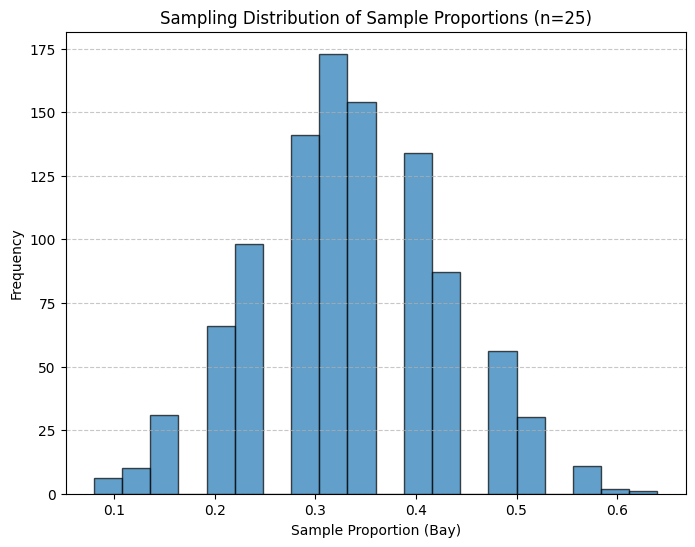

In [12]:
# plot
sample_size = 25
num_iterations = 1000

# Perform bootstrap sampling with n=25 and compute proportions from "Bay"
bay_proportions_n25 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n25.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n25, bins=20, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=25)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### $n = 100$

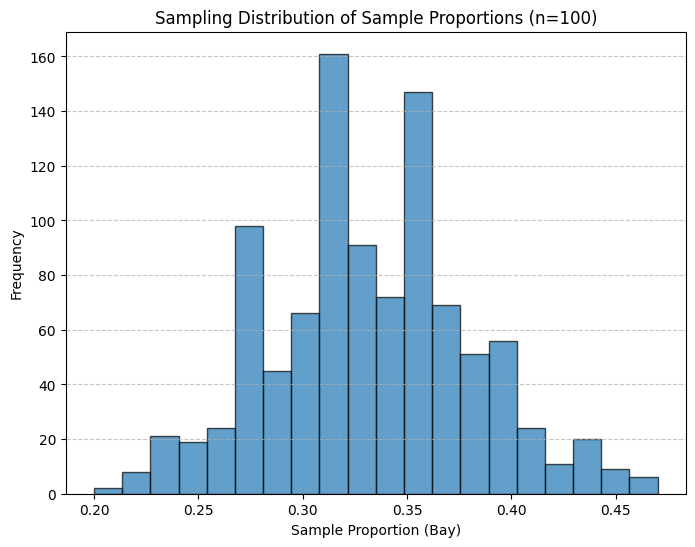

In [13]:
# plot
sample_size = 100
num_iterations = 1000

# Perform bootstrap sampling with n=100 and compute proportions from "Bay"
bay_proportions_n100 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n100.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n100, bins=20, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=100)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### $n = 1000$

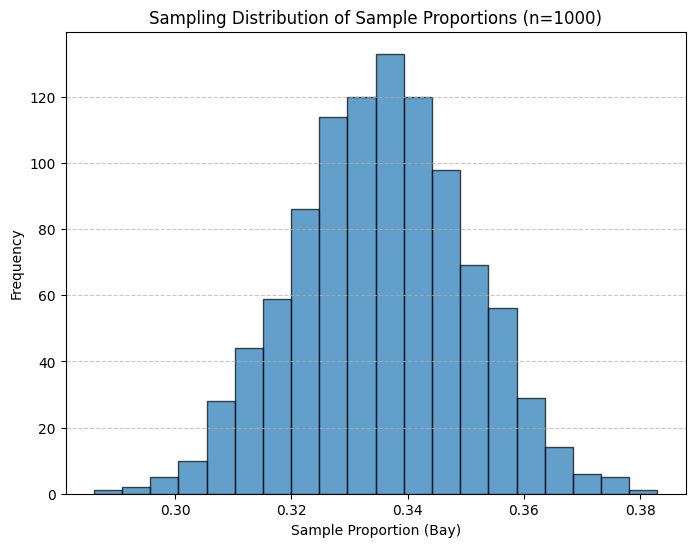

In [14]:
# plot
sample_size = 1000
num_iterations = 1000

# Perform bootstrap sampling with n=1000 and compute proportions from "Bay"
bay_proportions_n1000 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n1000.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n1000, bins=20, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=1000)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### $n = 5000$

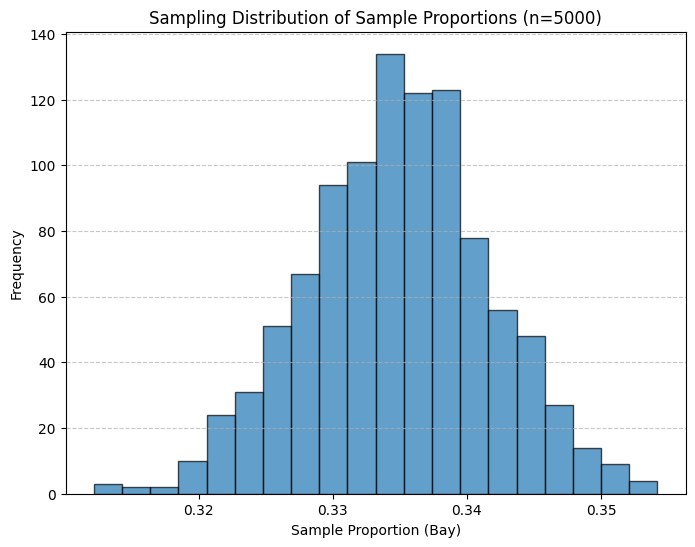

In [15]:
# plot
sample_size = 5000
num_iterations = 1000

# Perform bootstrap sampling with n=5000 and compute proportions from "Bay"
bay_proportions_n5000 = []
for _ in range(num_iterations):
    sample = bbnwr.sample(n=sample_size, replace=True)
    bay_proportion = (sample["Site_Id"] == "Bay").mean()
    bay_proportions_n5000.append(bay_proportion)

# Plot the sampling distribution of sample proportions
plt.figure(figsize=(8, 6))
plt.hist(bay_proportions_n5000, bins=20, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of Sample Proportions (n=5000)")
plt.xlabel("Sample Proportion (Bay)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation

What do you notice about these distributions? Comment on the shape of the distribution and the range of the x-axis.

**ANSWER:**

- As the sample size grows, the distribution becomes smoother and increasingly bell-shaped due to the Central Limit Theorem
- As n increases, the range of proportions narrows significantly, concentrating closer to the true population proportion (p=0.335021)


### Part (d)

Suppose we want to select a sample size where we would have a 90% probability of getting answer with 0.1 of the truth. Using the simulation results from (b), which sample sizes have 90% of the sample proportions within in the range:

In [17]:
(low, high) = (0.335021 - 0.1, 0.335021 + 0.1)

In [18]:
# answer
sample_sizes = [2, 10, 25, 100, 1000, 5000]
num_iterations = 1000

# Dictionary to store Bay proportions for each sample size
bay_proportions = {size: [] for size in sample_sizes}

# Perform bootstrap sampling for each sample size
for size in sample_sizes:
    for _ in range(num_iterations):
        sample = bbnwr.sample(n=size, replace=True)
        bay_proportion = (sample["Site_Id"] == "Bay").mean()
        bay_proportions[size].append(bay_proportion)

# Define the range for proportions
low, high = 0.335021 - 0.1, 0.335021 + 0.1

# Calculate the percentage of proportions within the range for each sample size
within_range_percentages = {
    size: sum(low <= proportion <= high for proportion in bay_proportions[size]) / num_iterations * 100
    for size in sample_sizes
}

# Display results as a table
results_df = pd.DataFrame({
    "Sample Size": sample_sizes,
    "Percentage Within Range (%)": [within_range_percentages[size] for size in sample_sizes]
})

print(results_df)

   Sample Size  Percentage Within Range (%)
0            2                          0.0
1           10                         49.7
2           25                         69.8
3          100                         95.8
4         1000                        100.0
5         5000                        100.0


Comment on these results.

* Which asymtpotic result from class are we illustrating with this simulation?
* Does the sample size required to get a 90% chance of a sample proportion within 0.1 of the truth seem very large to you?


**ANSWER:**

- This simulation illustrates the Central Limit Theorem (CLT). The CLT states that as the sample size increases, the sampling distribution of the sample mean approaches a normal distribution, regardless of the population's original distribution
- To achieve a 90% probability of obtaining a sample proportion within
plus/minus 0.1 of the truth, a relatively large sample size is likely around n=1000 or more.
- The required sample size does seem large, but this is expected due to the relatively narrow margin and high confidence level (90%). Larger sample sizes reduce variability and ensure that most sample proportions are close to the true value.



## Question 2

In this problem we will use a population that Gaussian/Normal distributed. Remember that usually this is not the case; most populations are not "Normal" in their shape. When we take larger and larger idependent, identically distributed samples, **the sample mean** behaves like a Gaussian distribution. But the Gaussian distribution will make a good population to illustrate some features of sampling, so we will sample from it.

Here is an illustration of taking a sample of 200 independent, identically distributed Gaussian random variables where the population mean is 10 and the population standard deviation is 2.

<Axes: ylabel='Count'>

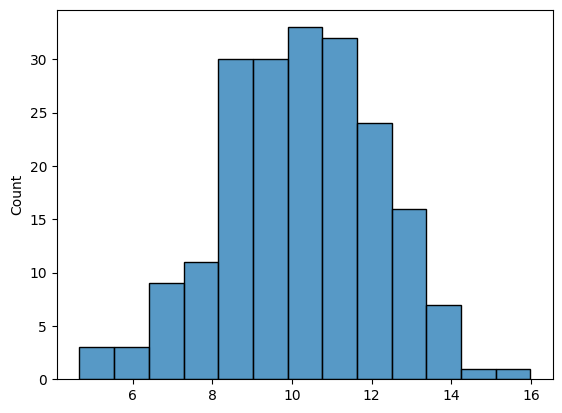

In [19]:
from numpy.random import normal

s = normal(10, 2, 200) # mean, sd, size of sample
sb.histplot(x = s)

### Part (a)

Suppose that a friend claims that the mean of a population is 10 or less, but you think it must be more than 10. You both agree that the population has a Gaussian distribution with a standard deviation of 8.

To resolve your debate, you agree to the following strategy:

- Take a sample of 100 units from the population.
- Compute the sample mean.
- If the sample mean is greater than 11, then you will consider that sufficient evidence against your friend's claim.
- If the sample mean is less than 11, you will agree that you do not have evidence against your friend's claim.

Perform a simulation in which your friend is correct about the population, and the actual mean is 10. Take samples of size 100 from a Gaussian distribution with a mean of 10 and a standard deviation of 8. For each sample, compute the sample mean. Repeat the simulation 10,000 times.

Number of sample means greater than 11: 1072
Proportion of sample means greater than 11: 0.1072


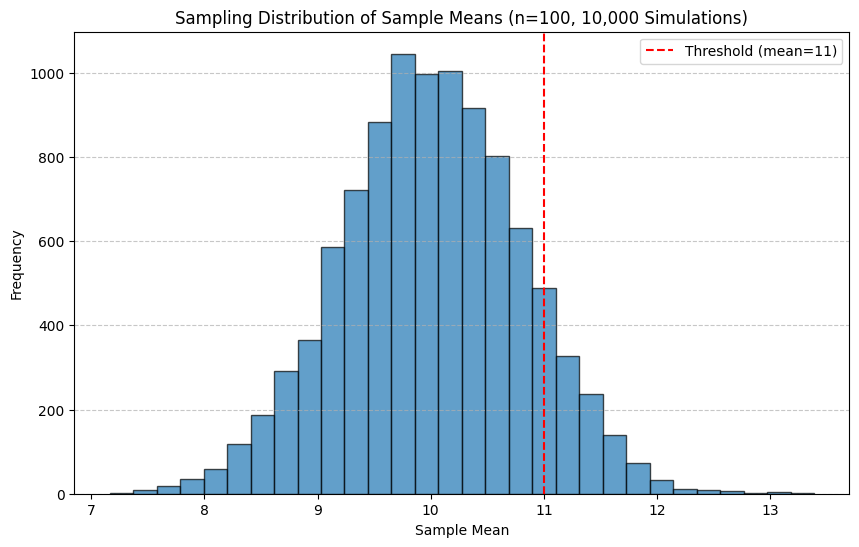

In [24]:
# simulation
#parameters
population_mean = 10
population_std_dev = 8
sample_size = 100
num_simulations = 10000

sample_means = []
for _ in range(num_simulations):
    sample = np.random.normal(population_mean, population_std_dev, sample_size)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

count_greater_than_11 = np.sum(sample_means > 11)
proportion_greater_than_11 = count_greater_than_11 / num_simulations

#print
print(f"Number of sample means greater than 11: {count_greater_than_11}")
print(f"Proportion of sample means greater than 11: {proportion_greater_than_11:.4f}")

#plot
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(11, color='red', linestyle='dashed', linewidth=1.5, label='Threshold (mean=11)')
plt.title("Sampling Distribution of Sample Means (n=100, 10,000 Simulations)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In this situation, you would be making an error if you decided to reject your friend's claim. In what proportion of samples would your make an error (i.e., the sample mean is greater than 11)?

In [26]:
# proportion rejected
# Parameters for the population
population_mean = 10
population_std_dev = 8
sample_size = 100
num_simulations = 10000

# Simulate 10,000 samples of size 100 from a Gaussian distribution
sample_means = []
for _ in range(num_simulations):
    sample = np.random.normal(population_mean, population_std_dev, sample_size)
    sample_means.append(np.mean(sample))

# Convert to a NumPy array for easier analysis
sample_means = np.array(sample_means)

# Count how many sample means are greater than 11 (proportion rejected)
count_rejected = np.sum(sample_means > 11)
proportion_rejected = count_rejected / num_simulations

# Print the results
print(f"Number of rejected samples (sample mean > 11): {count_rejected}")
print(f"Proportion of rejected samples: {proportion_rejected:.4f}")

Number of rejected samples (sample mean > 11): 1049
Proportion of rejected samples: 0.1049


### Part (b)

Now consider the case where you are correct. Repeat this simulation but now make the population mean equal to 10.5. How often do you make the correct decision (i.e., the sample mean is greater than 11)?

In [28]:
# simulation, proportion rejected
# Parameters for the population
population_mean = 10.5
population_std_dev = 8
sample_size = 100
num_simulations = 10000

# Simulate 10,000 samples of size 100 from a Gaussian distribution
sample_means = []
for _ in range(num_simulations):
    sample = np.random.normal(population_mean, population_std_dev, sample_size)
    sample_means.append(np.mean(sample))

# Convert to a NumPy array for easier analysis
sample_means = np.array(sample_means)

# Count how many sample means are greater than 11 (correct decision)
count_correct_decision = np.sum(sample_means > 11)
proportion_correct_decision = count_correct_decision / num_simulations

# Print the results
print(f"Number of correct decisions (sample mean > 11): {count_correct_decision}")
print(f"Proportion of correct decisions: {proportion_correct_decision:.4f}")

Number of correct decisions (sample mean > 11): 2646
Proportion of correct decisions: 0.2646


### Part (c)

In the Gaussian distribution, the mean and the median are the same value (because the distribution is symmetrical around the mean/median).

Repeat the two simulations from (a) and (b), but this time compute sample medians and use the decision rule that you will reject your friends claim if it is greater than 11.21. Report the probability of making an error when your friend is correct and the probabily of making the right decision when you are correct.

In [29]:
# repeat simulations using median, 11.21 cutoff
# Parameters for the population
population_std_dev = 8
sample_size = 100
num_simulations = 10000
threshold = 11.21

# Case 1: Friend is correct (population mean = 10)
population_mean_friend_correct = 10
sample_medians_friend_correct = []
for _ in range(num_simulations):
    sample = np.random.normal(population_mean_friend_correct, population_std_dev, sample_size)
    sample_medians_friend_correct.append(np.median(sample))

# Calculate the proportion of errors (sample median > threshold)
sample_medians_friend_correct = np.array(sample_medians_friend_correct)
count_error_friend_correct = np.sum(sample_medians_friend_correct > threshold)
proportion_error_friend_correct = count_error_friend_correct / num_simulations

# Case 2: You are correct (population mean = 10.5)
population_mean_you_correct = 10.5
sample_medians_you_correct = []
for _ in range(num_simulations):
    sample = np.random.normal(population_mean_you_correct, population_std_dev, sample_size)
    sample_medians_you_correct.append(np.median(sample))

# Calculate the proportion of correct decisions (sample median > threshold)
sample_medians_you_correct = np.array(sample_medians_you_correct)
count_correct_decision_you_correct = np.sum(sample_medians_you_correct > threshold)
proportion_correct_decision_you_correct = count_correct_decision_you_correct / num_simulations

# Print results
print(f"Case 1: Friend is correct (mean = 10)")
print(f"Proportion of errors (sample median > {threshold}): {proportion_error_friend_correct:.4f}")

print(f"\nCase 2: You are correct (mean = 10.5)")
print(f"Proportion of correct decisions (sample median > {threshold}): {proportion_correct_decision_you_correct:.4f}")

Case 1: Friend is correct (mean = 10)
Proportion of errors (sample median > 11.21): 0.1105

Case 2: You are correct (mean = 10.5)
Proportion of correct decisions (sample median > 11.21): 0.2400


In this question and the previous we used two different methods to make an inference about the population. We would reject the claim that the population mean is less than or equal to 10 if

* the sample mean is greater than 11, or
* the sample median is greater 11.21

Compare using the two different methods on their respective probabilities of making an error when the population mean is 10 and of making the right decision when then population mean is 10.5. Based on these results, which of these two methods works as a better technique for making inference about population means?

**ANSWER:**

The sample mean is a better technique for making inferences about population means in this scenario because it provides higher accuracy (lower Type I error rate) and greater power (higher probability of correct decisions).